# Module: Local Search

Local search keeps one state (or a small population) instead of a path, and moves to nearby states
to improve an objective. It needs little memory but gives up the guarantees of systematic search.

| # | Algorithm | Keeps in memory |
|---|---|---|
| 1 | Simple Hill Climbing | one state |
| 2 | Steepest-Ascent Hill Climbing | one state |
| 3 | Simulated Annealing | one state + a temperature |
| 4 | Genetic Algorithm | a population of states |

**Running problem: Travelling Salesperson (TSP).** Start at a city, visit every other city once,
return, and minimise the total distance.

- **Graph:** the same adjacency dict, `graph[u][v]` = distance. Every pair of cities is connected.
- **State:** a list of cities that starts with the start city, e.g. `['A', 'D', 'B', 'C']`. The return edge is implied.
- **Cost:** tour length, including the return edge.
- **Neighbour:** swap two cities; the start city stays in place.

Each function returns `(tour, cost, evaluations, iterations)`. *Evaluations* counts the tours whose
cost we computed, the local-search stand-in for nodes expanded.

In [1]:
import math
import random

def tour_cost(graph, tour):
    """Total length of a closed tour (returns to tour[0] at the end)."""
    return sum(graph[tour[i]][tour[(i + 1) % len(tour)]] for i in range(len(tour)))

def random_tour(graph, start, rng):
    others = [c for c in graph if c != start]
    rng.shuffle(others)
    return [start] + others

<h2><b>1. Simple Hill Climbing</b></h2>

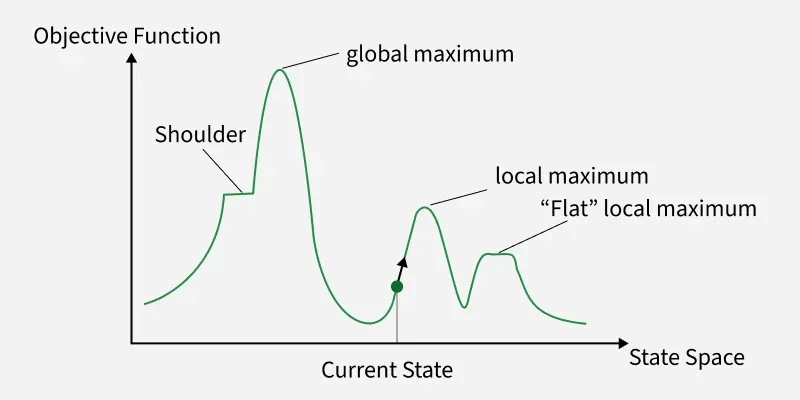

GIF source: https://www.geeksforgeeks.org/artificial-intelligence/introduction-hill-climbing-artificial-intelligence/

Simple hill climbing starts from a random tour and looks at its neighbours one at a time, in a fixed
order. It moves to the **first** neighbour that is strictly shorter, without looking at the rest,
and starts scanning again from the new tour. When a full scan finds no shorter neighbour, it stops.

It keeps only the current tour. The image shows the landscape every hill climber moves on: it
climbs whatever slope is under it and stops at the first peak, which may be a local maximum, a flat
local maximum or a shoulder rather than the global maximum (for TSP, "higher" means a shorter tour).
Each step is cheap, because it usually stops scanning early, but each step may improve the tour
only a little.

**Step-by-step mechanism of Simple Hill Climbing:**

- Build a random initial tour (start city first) and compute its cost.
- Loop:
  - Go through the swaps of two non-start cities in a fixed order, computing each neighbour's cost.
  - As soon as a neighbour is strictly cheaper than the current tour, move to it and start the
    loop again.
  - If the whole scan finds no cheaper neighbour, stop and return the current tour. This is a
    **local optimum** (there is no explicit failure signal).

**Properties of Simple Hill Climbing**

| Complete? | Optimal? | Memory use | Failure modes (local optimum / plateau / ridge) |
|---|---|---|---|
| No | No | O(1) states | Stops at local optima and on plateaus; stalls on ridges |

- **Complete?** It always halts, possibly at a poor state, and has no way to continue from there.
- **Optimal?** It only guarantees that no single swap improves the tour.
- **Memory use:** the current tour and one neighbour.
- **Cost per step:** anywhere from one evaluation to a full scan; only the final step (the one that finds nothing) always scans every swap.
- **Failure modes:** the same as steepest ascent. Because it takes the first improvement rather than the best, it follows a different path and often ends at a different local optimum.

**Case study.** Wulan, a courier, leaves the depot **A** every morning, delivers to seven drop-off
points (B–H) and returns. She starts from a random order and swaps two stops whenever that shortens
the route. Distances are in km.

In [2]:
courier_map = {
    'A': {'B': 26, 'C': 22, 'D': 65, 'E': 33, 'F': 69, 'G': 52, 'H': 19},
    'B': {'A': 26, 'C': 6, 'D': 90, 'E': 33, 'F': 84, 'G': 77, 'H': 45},
    'C': {'A': 22, 'B': 6, 'D': 84, 'E': 34, 'F': 82, 'G': 73, 'H': 40},
    'D': {'A': 65, 'B': 90, 'C': 84, 'E': 93, 'F': 94, 'G': 49, 'H': 53},
    'E': {'A': 33, 'B': 33, 'C': 34, 'D': 93, 'F': 54, 'G': 62, 'H': 41},
    'F': {'A': 69, 'B': 84, 'C': 82, 'D': 94, 'E': 54, 'G': 45, 'H': 58},
    'G': {'A': 52, 'B': 77, 'C': 73, 'D': 49, 'E': 62, 'F': 45, 'H': 34},
    'H': {'A': 19, 'B': 45, 'C': 40, 'D': 53, 'E': 41, 'F': 58, 'G': 34},
}

In [3]:
def simple_hill_climbing(graph, start, seed=None, verbose=False):
    """Simple (first-improvement) hill climbing on TSP with swap neighbours.
    Returns (tour, cost, evaluations, iterations)."""
    rng = random.Random(seed)
    current = random_tour(graph, start, rng)
    current_cost = tour_cost(graph, current)
    evaluations, iterations = 1, 0
    if verbose:
        print(f"start     cost = {current_cost}  tour = {current}")

    improved = True
    while improved:
        improved = False
        for i in range(1, len(current) - 1):          # position 0 is the fixed start city
            for j in range(i + 1, len(current)):
                neighbor = current[:]
                neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
                cost = tour_cost(graph, neighbor)
                evaluations += 1
                if cost < current_cost:               # first strict improvement: take it
                    current, current_cost = neighbor, cost
                    improved = True
                    break
            if improved:
                break
        if improved:
            iterations += 1
            if verbose:
                print(f"step {iterations:<4} cost = {current_cost}  tour = {current}")

    return current, current_cost, evaluations, iterations

In [4]:
tour, cost, evaluations, iterations = simple_hill_climbing(courier_map, 'A', seed=0, verbose=True)
print()
print("Final tour  :", " -> ".join(tour + [tour[0]]))
print("Cost        :", cost)
print("Iterations  :", iterations)
print("Evaluations :", evaluations)

print("\nFive different random starts:")
for seed in range(5):
    tour, cost, evaluations, iterations = simple_hill_climbing(courier_map, 'A', seed=seed)
    print(f"  seed {seed}: cost = {cost:>3}  iterations = {iterations:>2}  evaluations = {evaluations:>3}  tour = {' -> '.join(tour + [tour[0]])}")

start     cost = 452  tour = ['A', 'F', 'D', 'C', 'B', 'G', 'E', 'H']
step 1    cost = 446  tour = ['A', 'D', 'F', 'C', 'B', 'G', 'E', 'H']
step 2    cost = 428  tour = ['A', 'G', 'F', 'C', 'B', 'D', 'E', 'H']
step 3    cost = 367  tour = ['A', 'E', 'F', 'C', 'B', 'D', 'G', 'H']
step 4    cost = 355  tour = ['A', 'F', 'E', 'C', 'B', 'D', 'G', 'H']
step 5    cost = 353  tour = ['A', 'H', 'E', 'C', 'B', 'D', 'G', 'F']
step 6    cost = 349  tour = ['A', 'B', 'E', 'C', 'H', 'D', 'G', 'F']
step 7    cost = 328  tour = ['A', 'E', 'B', 'C', 'H', 'D', 'G', 'F']
step 8    cost = 318  tour = ['A', 'C', 'B', 'E', 'H', 'D', 'G', 'F']
step 9    cost = 311  tour = ['A', 'C', 'B', 'E', 'F', 'D', 'G', 'H']
step 10   cost = 281  tour = ['A', 'C', 'B', 'E', 'F', 'G', 'D', 'H']

Final tour  : A -> C -> B -> E -> F -> G -> D -> H -> A
Cost        : 281
Iterations  : 10
Evaluations : 82

Five different random starts:
  seed 0: cost = 281  iterations = 10  evaluations =  82  tour = A -> C -> B -> E -> F -> 

With seed 0, Wulan reaches 281 km, the best route on this map (checked separately by enumerating
all 5,040 tours), in 10 small steps and 82 evaluations. Seeds 1, 3 and 4 stop at 306 or 311 km:
local optima where no single swap helps. On the same five starts, steepest ascent (next section)
needs only 3–6 steps but 85–148 evaluations, and reaches 281 from every start except seed 1.

<h2><b>2. Steepest-Ascent Hill Climbing</b></h2>

![](data\steepest_ascent.gif)

GIF source: generated for this module with matplotlib (same swap neighbours as the code below)

Steepest-ascent hill climbing starts from a random tour, scores **every** neighbour, and moves to the
best one as long as it is strictly shorter. When no neighbour improves, it stops.

It keeps only the current tour and the best neighbour seen during a scan: no stack, queue or
visited set. Compared with simple hill climbing, each step costs a full scan of the neighbourhood,
but it makes the biggest improvement available, so it needs fewer steps. Like simple hill
climbing, it never backtracks: once every neighbour is worse it stays put, even if a better tour
exists elsewhere.

**Step-by-step mechanism of Steepest-Ascent Hill Climbing:**

- Build a random initial tour (start city first) and compute its cost.
- Loop:
  - Generate every neighbour by swapping two non-start cities, and compute each neighbour's cost.
  - Keep the neighbour with the lowest cost.
  - If that cost is strictly lower than the current cost, move to that neighbour and repeat.
  - Otherwise no neighbour is better: stop and return the current tour. This is a **local
    optimum**, which may or may not be the global optimum (there is no explicit failure signal).

**Properties of Steepest-Ascent Hill Climbing**

| Complete? | Optimal? | Memory use | Failure modes (local optimum / plateau / ridge) |
|---|---|---|---|
| No | No | O(1) states | Stops at local optima and on plateaus; stalls on ridges |

- **Complete?** It always halts, possibly at a poor state, and has no way to continue from there.
- **Optimal?** It only guarantees that no single swap improves the tour.
- **Memory use:** two tours (current and best neighbour), whatever the size of the state space.
- **Cost per step:** all n(n−1)/2 swaps are evaluated before each move, where n is the number of non-start cities.
- **Failure modes:** it halts at any local optimum; it stops on a plateau because it demands strict improvement; on a ridge, progress needs two moves at once, which no single neighbour offers.

**Case study.** Dimas, a sales rep, leaves head office **A** each week, visits branches B–H once
and returns. He starts from a random order and keeps making the best swap. The result depends on
the start, so we try five seeds. Distances are in km.

In [5]:
sales_map = {
    'A': {'B': 102, 'C': 59, 'D': 52, 'E': 42, 'F': 70, 'G': 95, 'H': 11},
    'B': {'A': 102, 'C': 65, 'D': 95, 'E': 66, 'F': 42, 'G': 18, 'H': 101},
    'C': {'A': 59, 'B': 65, 'D': 88, 'E': 51, 'F': 61, 'G': 69, 'H': 51},
    'D': {'A': 52, 'B': 95, 'C': 88, 'E': 37, 'F': 53, 'G': 80, 'H': 62},
    'E': {'A': 42, 'B': 66, 'C': 51, 'D': 37, 'F': 29, 'G': 55, 'H': 45},
    'F': {'A': 70, 'B': 42, 'C': 61, 'D': 53, 'E': 29, 'G': 28, 'H': 72},
    'G': {'A': 95, 'B': 18, 'C': 69, 'D': 80, 'E': 55, 'F': 28, 'H': 95},
    'H': {'A': 11, 'B': 101, 'C': 51, 'D': 62, 'E': 45, 'F': 72, 'G': 95},
}

In [6]:
def steepest_ascent_hill_climbing(graph, start, seed=None, verbose=False):
    """Steepest-ascent hill climbing on TSP with swap neighbours.
    Returns (tour, cost, evaluations, iterations)."""
    rng = random.Random(seed)
    current = random_tour(graph, start, rng)
    current_cost = tour_cost(graph, current)
    evaluations, iterations = 1, 0
    if verbose:
        print(f"start     cost = {current_cost}  tour = {current}")

    while True:
        best_neighbor, best_cost = None, current_cost
        for i in range(1, len(current) - 1):          # position 0 is the fixed start city
            for j in range(i + 1, len(current)):
                neighbor = current[:]
                neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
                cost = tour_cost(graph, neighbor)
                evaluations += 1
                if cost < best_cost:                  # strict improvement only
                    best_neighbor, best_cost = neighbor, cost
        if best_neighbor is None:                     # no better neighbour: local optimum
            break
        current, current_cost = best_neighbor, best_cost
        iterations += 1
        if verbose:
            print(f"step {iterations:<4} cost = {current_cost}  tour = {current}")

    return current, current_cost, evaluations, iterations

In [7]:
tour, cost, evaluations, iterations = steepest_ascent_hill_climbing(sales_map, 'A', seed=0, verbose=True)
print()
print("Final tour  :", " -> ".join(tour + [tour[0]]))
print("Cost        :", cost)
print("Iterations  :", iterations)
print("Evaluations :", evaluations)

print("\nFive different random starts:")
for seed in range(5):
    tour, cost, evaluations, iterations = steepest_ascent_hill_climbing(sales_map, 'A', seed=seed)
    print(f"  seed {seed}: cost = {cost:>3}  iterations = {iterations}  tour = {' -> '.join(tour + [tour[0]])}")

start     cost = 405  tour = ['A', 'F', 'D', 'C', 'B', 'G', 'E', 'H']
step 1    cost = 360  tour = ['A', 'D', 'F', 'C', 'B', 'G', 'E', 'H']
step 2    cost = 323  tour = ['A', 'D', 'F', 'G', 'B', 'C', 'E', 'H']

Final tour  : A -> D -> F -> G -> B -> C -> E -> H -> A
Cost        : 323
Iterations  : 2
Evaluations : 64

Five different random starts:
  seed 0: cost = 323  iterations = 2  tour = A -> D -> F -> G -> B -> C -> E -> H -> A
  seed 1: cost = 309  iterations = 5  tour = A -> H -> D -> E -> F -> G -> B -> C -> A
  seed 2: cost = 291  iterations = 3  tour = A -> D -> E -> F -> G -> B -> C -> H -> A
  seed 3: cost = 309  iterations = 2  tour = A -> H -> D -> E -> F -> G -> B -> C -> A
  seed 4: cost = 309  iterations = 5  tour = A -> H -> D -> E -> F -> G -> B -> C -> A


Only seed 2 reaches 291, the best tour on this map (checked separately by enumerating all 5,040
tours). Seeds 1, 3 and 4 stop at the same 309 tour, a local optimum. Random restarts fix much of
this: run from many starts and keep the best result.

<h2><b>3. Simulated Annealing</b></h2>

![](data\simulated_annealing.gif)

GIF source: https://commons.wikimedia.org/wiki/File:Travelling_salesman_problem_solved_with_simulated_annealing.gif (CC0)

Simulated annealing picks a random neighbour at each step. It always accepts a better one, and
accepts a worse one with probability e<sup>−Δ/T</sup>, where Δ is how much worse it is and T is the
temperature. T starts high and shrinks each step, so the search wanders early and settles later.

It stores the current tour, the temperature and the best tour so far. Compared with steepest-ascent hill climbing,
it can move downhill, which lets it leave a local optimum. Each step checks one neighbour instead
of all of them, so steps are cheap but it needs many more of them.

**Step-by-step mechanism of Simulated Annealing:**

- Build a random initial tour, compute its cost, and remember it as the best tour so far.
- Set the temperature T = T<sub>0</sub>.
- Loop while T > T<sub>min</sub>:
  - Pick two random non-start positions and swap them to get a neighbour; compute its cost.
  - Let Δ = neighbour cost − current cost.
  - If Δ < 0, accept the neighbour. Otherwise accept it with probability e<sup>−Δ/T</sup>.
  - If the accepted tour beats the best tour so far, remember it.
  - Cool down: T ← α · T (with 0 < α < 1).
- When T falls below T<sub>min</sub>, stop and return the best tour found. As with hill climbing,
  there is no explicit failure: the result is simply the best tour reached.

**Properties of Simulated Annealing**

| Complete? | Optimal? | Memory use | Failure modes (local optimum / plateau / ridge) |
|---|---|---|---|
| No | No in practice | O(1) states | Handles all three while T is high; freezes in a local optimum if cooled too fast |

- **Complete?** A finite cooling schedule stops it after a fixed number of steps, solved or not.
- **Optimal?** It reaches the global optimum with probability 1 only if T drops impossibly slowly.
- **Memory use:** current tour, best tour and a temperature.
- **Failure modes:** at high T, downhill moves let it escape local optima and cross plateaus and ridges; at low T it acts like a random hill climber, so fast cooling traps it.

**Case study.** Lala flies an inspection drone from its charging pad **A** to seven wind turbines
(B–H) and back. Distances are in hundreds of metres.

In [8]:
turbine_map = {
    'A': {'B': 35, 'C': 84, 'D': 83, 'E': 71, 'F': 69, 'G': 63, 'H': 81},
    'B': {'A': 35, 'C': 49, 'D': 75, 'E': 38, 'F': 35, 'G': 29, 'H': 81},
    'C': {'A': 84, 'B': 49, 'D': 84, 'E': 20, 'F': 18, 'G': 26, 'H': 99},
    'D': {'A': 83, 'B': 75, 'C': 84, 'E': 65, 'F': 69, 'G': 88, 'H': 19},
    'E': {'A': 71, 'B': 38, 'C': 20, 'D': 65, 'F': 5, 'G': 28, 'H': 79},
    'F': {'A': 69, 'B': 35, 'C': 18, 'D': 69, 'E': 5, 'G': 23, 'H': 83},
    'G': {'A': 63, 'B': 29, 'C': 26, 'D': 88, 'E': 28, 'F': 23, 'H': 99},
    'H': {'A': 81, 'B': 81, 'C': 99, 'D': 19, 'E': 79, 'F': 83, 'G': 99},
}

In [9]:
def simulated_annealing(graph, start, t0=100.0, alpha=0.999, t_min=0.01, seed=None, verbose=False):
    """Simulated annealing on TSP with random swap neighbours.
    Returns (best_tour, best_cost, evaluations, iterations)."""
    rng = random.Random(seed)
    current = random_tour(graph, start, rng)
    current_cost = tour_cost(graph, current)
    best, best_cost = current[:], current_cost
    evaluations, iterations = 1, 0
    temperature = t0

    while temperature > t_min:
        i, j = rng.sample(range(1, len(current)), 2)  # never move the start city
        neighbor = current[:]
        neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
        neighbor_cost = tour_cost(graph, neighbor)
        evaluations += 1
        delta = neighbor_cost - current_cost
        if delta < 0 or rng.random() < math.exp(-delta / temperature):
            current, current_cost = neighbor, neighbor_cost
            if current_cost < best_cost:
                best, best_cost = current[:], current_cost
        temperature *= alpha
        iterations += 1
        if verbose and iterations % 1500 == 0:
            print(f"iter {iterations:>5}  T = {temperature:8.3f}  current = {current_cost:>3}  best = {best_cost:>3}")

    return best, best_cost, evaluations, iterations

In [10]:
tour, cost, evaluations, iterations = simulated_annealing(turbine_map, 'A', seed=0, verbose=True)
print()
print("Best tour   :", " -> ".join(tour + [tour[0]]))
print("Cost        :", cost)
print("Iterations  :", iterations)
print("Evaluations :", evaluations)

iter  1500  T =   22.296  current = 343  best = 284
iter  3000  T =    4.971  current = 278  best = 278
iter  4500  T =    1.108  current = 278  best = 278
iter  6000  T =    0.247  current = 278  best = 278
iter  7500  T =    0.055  current = 278  best = 278
iter  9000  T =    0.012  current = 278  best = 278

Best tour   : A -> H -> D -> E -> F -> C -> G -> B -> A
Cost        : 278
Iterations  : 9206
Evaluations : 9207


<h2><b>4. Genetic Algorithm</b></h2>

![](data\genetic_algorithm.gif)

GIF source: generated for this module with matplotlib (same GA operators as the code below)

A genetic algorithm (GA) evolves a population of tours. Each generation it picks good parents,
combines pairs with crossover, mutates some children, and carries the best tours forward.

The data is a list of tours with their costs. A TSP child must still visit each city once, so the
code uses ordered crossover: copy a slice from one parent, then fill the gaps in the order the
other parent visits those cities. Selection is a 3-way tournament, mutation swaps two cities, and
elitism copies the best 2 tours unchanged. Simulated annealing improves one tour in small steps; a
GA works with many tours and can join good pieces of two in a single step.

**Step-by-step mechanism of the Genetic Algorithm:**

- Create an initial population of random tours (start city fixed in position 0).
- Repeat for a fixed number of generations:
  - Evaluate the cost of every tour and sort the population from best to worst.
  - Copy the best `elite` tours unchanged into the new population (elitism).
  - Until the new population is full:
    - Pick two parents by tournament selection.
    - Create a child with ordered crossover.
    - With probability `mutation_rate`, swap two cities of the child.
    - Add the child to the new population.
  - Replace the old population with the new one.
- Evaluate the final population and return its best tour. There is no explicit failure: the
  result is the best tour the population reached.

**Properties of the Genetic Algorithm**

| Complete? | Optimal? | Memory use | Failure modes (local optimum / plateau / ridge) |
|---|---|---|---|
| No | No | O(P · n) for P tours of n cities | Premature convergence to a local optimum; slow on plateaus |

- **Complete?** It runs a fixed number of generations and returns what it has.
- **Optimal?** Elitism keeps the best tour from getting worse, nothing more.
- **Memory use:** P tours instead of one.
- **Failure modes:** once the population loses diversity, crossover recombines copies of the same tour; on a plateau selection has nothing to prefer; crossover can jump ridges that single swaps cannot.

**Case study.** Pak Joko's food truck leaves its kitchen **A** every evening, stops at seven
corners (B–H) and returns. His nephew suggests breeding routes: keep 30 candidates and let the best
ones produce the next generation. Distances are in hundreds of metres.

In [11]:
food_truck_map = {
    'A': {'B': 71, 'C': 17, 'D': 30, 'E': 80, 'F': 88, 'G': 52, 'H': 61},
    'B': {'A': 71, 'C': 65, 'D': 65, 'E': 9, 'F': 17, 'G': 19, 'H': 13},
    'C': {'A': 17, 'B': 65, 'D': 13, 'E': 74, 'F': 82, 'G': 46, 'H': 53},
    'D': {'A': 30, 'B': 65, 'C': 13, 'E': 73, 'F': 81, 'G': 47, 'H': 52},
    'E': {'A': 80, 'B': 9, 'C': 74, 'D': 73, 'F': 8, 'G': 29, 'H': 21},
    'F': {'A': 88, 'B': 17, 'C': 82, 'D': 81, 'E': 8, 'G': 36, 'H': 29},
    'G': {'A': 52, 'B': 19, 'C': 46, 'D': 47, 'E': 29, 'F': 36, 'H': 11},
    'H': {'A': 61, 'B': 13, 'C': 53, 'D': 52, 'E': 21, 'F': 29, 'G': 11},
}

In [12]:
def genetic_algorithm(graph, start, pop_size=30, generations=100, mutation_rate=0.2,
                      elite=2, tournament_size=3, seed=None, verbose=False):
    """Genetic algorithm on TSP. Returns (best_tour, best_cost, evaluations, generations)."""
    rng = random.Random(seed)
    evaluations = 0

    def evaluate(population):
        nonlocal evaluations
        evaluations += len(population)
        return sorted((tour_cost(graph, tour), tour) for tour in population)

    def tournament(ranked):
        contestants = rng.sample(ranked, tournament_size)
        return min(contestants)[1]                     # lowest cost wins

    def ordered_crossover(parent1, parent2):
        a, b = sorted(rng.sample(range(1, len(parent1)), 2))
        child = [None] * len(parent1)
        child[0] = start
        child[a:b + 1] = parent1[a:b + 1]              # copy a slice from parent 1
        remaining = [c for c in parent2[1:] if c not in child]
        for k in range(1, len(child)):                 # fill the gaps in parent 2 order
            if child[k] is None:
                child[k] = remaining.pop(0)
        return child

    def mutate(tour):
        i, j = rng.sample(range(1, len(tour)), 2)
        tour[i], tour[j] = tour[j], tour[i]

    population = [random_tour(graph, start, rng) for _ in range(pop_size)]
    for generation in range(1, generations + 1):
        ranked = evaluate(population)
        new_population = [tour for _, tour in ranked[:elite]]   # elitism
        while len(new_population) < pop_size:
            child = ordered_crossover(tournament(ranked), tournament(ranked))
            if rng.random() < mutation_rate:
                mutate(child)
            new_population.append(child)
        population = new_population
        if verbose and generation % 20 == 0:
            print(f"generation {generation:>3}  best cost so far = {ranked[0][0]}")

    best_cost, best = evaluate(population)[0]
    return best, best_cost, evaluations, generations

In [13]:
tour, cost, evaluations, generations = genetic_algorithm(food_truck_map, 'A', seed=0, verbose=True)
print()
print("Best tour   :", " -> ".join(tour + [tour[0]]))
print("Cost        :", cost)
print("Generations :", generations)
print("Evaluations :", evaluations)

generation  20  best cost so far = 199
generation  40  best cost so far = 199
generation  60  best cost so far = 199
generation  80  best cost so far = 199
generation 100  best cost so far = 199

Best tour   : A -> C -> D -> H -> E -> F -> B -> G -> A
Cost        : 199
Generations : 100
Evaluations : 3030


## Comparison

All four algorithms on one 10-city TSP instance, seed 0. Here *nodes expanded* means tours
evaluated, and *path* is the tour.

In [14]:
tsp_map = {
    'A': {'B': 57, 'C': 30, 'D': 29, 'E': 42, 'F': 38, 'G': 59, 'H': 25, 'I': 47, 'J': 16},
    'B': {'A': 57, 'C': 48, 'D': 81, 'E': 90, 'F': 44, 'G': 25, 'H': 64, 'I': 58, 'J': 66},
    'C': {'A': 30, 'B': 48, 'D': 59, 'E': 72, 'F': 9, 'G': 38, 'H': 54, 'I': 17, 'J': 26},
    'D': {'A': 29, 'B': 81, 'C': 59, 'E': 14, 'F': 67, 'G': 88, 'H': 21, 'I': 74, 'J': 36},
    'E': {'A': 42, 'B': 90, 'C': 72, 'D': 14, 'F': 80, 'G': 99, 'H': 26, 'I': 88, 'J': 50},
    'F': {'A': 38, 'B': 44, 'C': 9, 'D': 67, 'E': 80, 'G': 30, 'H': 61, 'I': 15, 'J': 35},
    'G': {'A': 59, 'B': 25, 'C': 38, 'D': 88, 'E': 99, 'F': 30, 'H': 75, 'I': 41, 'J': 63},
    'H': {'A': 25, 'B': 64, 'C': 54, 'D': 21, 'E': 26, 'F': 61, 'G': 75, 'I': 71, 'J': 40},
    'I': {'A': 47, 'B': 58, 'C': 17, 'D': 74, 'E': 88, 'F': 15, 'G': 41, 'H': 71, 'J': 39},
    'J': {'A': 16, 'B': 66, 'C': 26, 'D': 36, 'E': 50, 'F': 35, 'G': 63, 'H': 40, 'I': 39},
}

In [15]:
def print_table(rows):
    header = f"{'algorithm':<22} | {'path':<52} | {'cost':>5} | {'nodes expanded':>14}"
    print(header)
    print("-" * len(header))
    for name, path, cost, expanded in rows:
        print(f"{name:<22} | {' -> '.join(path):<52} | {cost:>5} | {expanded:>14}")

rows = []
for name, algorithm in [('Simple Hill Climbing', simple_hill_climbing),
                        ('Steepest-Ascent HC', steepest_ascent_hill_climbing),
                        ('Simulated Annealing', simulated_annealing),
                        ('Genetic Algorithm', genetic_algorithm)]:
    tour, cost, evaluations, _ = algorithm(tsp_map, 'A', seed=0)
    rows.append((name, tour + [tour[0]], cost, evaluations))
print_table(rows)

# one run per algorithm is noisy, so repeat each one with 10 different seeds
print("\nSame instance, seeds 0-9:")
for name, algorithm in [('Simple Hill Climbing', simple_hill_climbing),
                        ('Steepest-Ascent HC', steepest_ascent_hill_climbing),
                        ('Simulated Annealing', simulated_annealing),
                        ('Genetic Algorithm', genetic_algorithm)]:
    costs = [algorithm(tsp_map, 'A', seed=seed)[1] for seed in range(10)]
    print(f"  {name:<22} costs = {costs}  best = {min(costs)}  mean = {sum(costs) / len(costs):.1f}")

algorithm              | path                                                 |  cost | nodes expanded
------------------------------------------------------------------------------------------------------
Simple Hill Climbing   | A -> C -> I -> J -> D -> E -> H -> B -> G -> F -> A  |   319 |            149
Steepest-Ascent HC     | A -> B -> G -> F -> I -> C -> J -> D -> E -> H -> A  |   271 |            217
Simulated Annealing    | A -> D -> E -> H -> B -> G -> F -> I -> C -> J -> A  |   262 |           9207
Genetic Algorithm      | A -> H -> E -> D -> J -> C -> I -> F -> G -> B -> A  |   271 |           3030

Same instance, seeds 0-9:
  Simple Hill Climbing   costs = [319, 320, 319, 271, 311, 338, 330, 271, 271, 313]  best = 271  mean = 306.3
  Steepest-Ascent HC     costs = [271, 339, 310, 339, 273, 262, 292, 271, 271, 271]  best = 262  mean = 289.9


  Simulated Annealing    costs = [262, 262, 275, 262, 262, 265, 262, 262, 265, 269]  best = 262  mean = 264.6


  Genetic Algorithm      costs = [271, 262, 271, 273, 271, 271, 262, 271, 262, 271]  best = 262  mean = 268.5


With seed 0, simple hill climbing stops at 319 after 149 evaluations, and steepest ascent at 271
after 217. The GA spends 3,030 evaluations and ends on the same 271 tour in reverse. Simulated
annealing spends 9,207 and reaches 262, the true optimum (checked separately by enumerating all
362,880 tours). Across ten seeds, simple hill climbing averages 306.3 and steepest ascent 289.9:
both stop at the first local optimum, but taking the best swap each step lands on better ones more
often. SA averages 264.6 and the GA 268.5: the evaluations they spend escaping local optima buy
better and steadier tours.